<a href="https://colab.research.google.com/github/dipeshsoni23/Deep_Learning/blob/main/DL_Assignment_Sentiment140_CNN_BiLSTM_DIPESH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 1: Dataset Identification**

In [30]:
import pandas as pd
import zipfile
import os

zip_filename = "archive.zip"
csv_filename = "training.1600000.processed.noemoticon.csv"

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset_folder')

print("Extracted files:", os.listdir('/content/dataset_folder'))

file_path = f'/content/dataset_folder/{csv_filename}'
df = pd.read_csv(file_path, encoding='latin1', header=None)

df.columns = ['polarity', 'id', 'date', 'query', 'user', 'text']

print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())

df['sentiment'] = df['polarity'].map({0: 'negative', 4: 'positive'})

print("Class Distribution:")
print(df['sentiment'].value_counts())

print("Sample 4 Rows:")
print(df[['text', 'sentiment']].head(4).to_string(index=True))

Extracted files: ['training.1600000.processed.noemoticon.csv']
Dataset Shape: (1600000, 6)
Columns: ['polarity', 'id', 'date', 'query', 'user', 'text']
Class Distribution:
sentiment
negative    800000
positive    800000
Name: count, dtype: int64
Sample 4 Rows:
                                                                                                                  text sentiment
0  @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D  negative
1      is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!  negative
2                            @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds  negative
3                                                                      my whole body feels itchy and like its on fire   negative


# **TASK 2: Data Understanding and Preprocessing**


Task 2 Started...
Original Shape: (1600000, 7)
 After sampling 50k balanced samples → Shape: (50000, 7)
Cleaning text...
 Cleaned dataset shape: (50000, 2)
 Normalization/Standardization Applied:
X shape: (50000, 200) | y shape: (50000,)

Train-Validation-Test Split:
Train set     : 25,000 samples
Validation set: 12,500 samples
Test set      : 12,500 samples


/tmp/ipykernel_1000/822034226.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_sample['sentiment'], palette=['#e74c3c', '#2ecc71'])


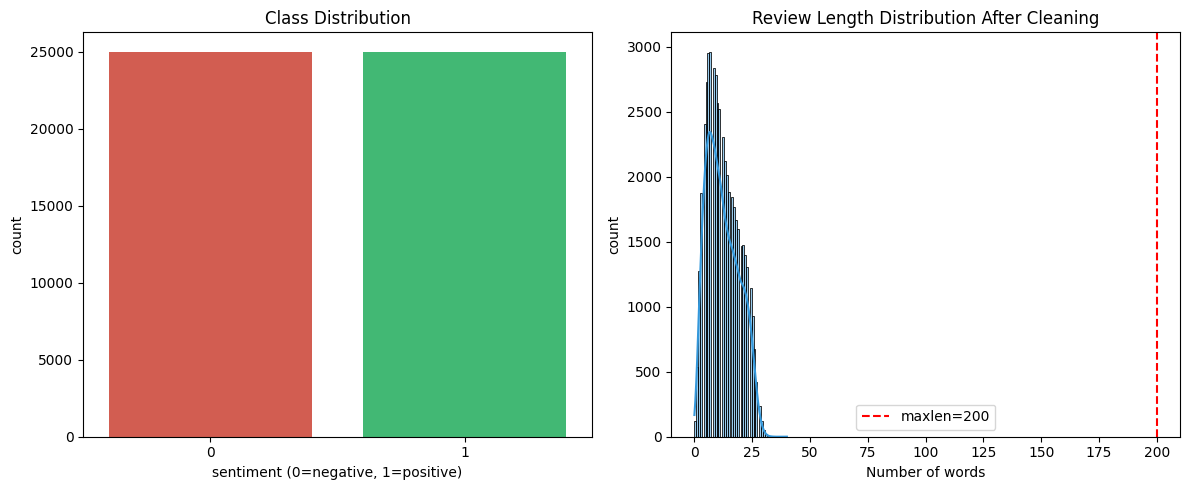


Sample Padded Sequences:

Example 1:
Original : @indykitty *hug indykitty* sleep tight indy... 
Cleaned  : hug indykitty sleep tight indy
Padded Sequence (first 30 tokens): [ 802    1  116 1805 3344    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
Original Length: 5  | Padded Length: 200

Example 2:
Original : @Shough yeah I feel really bad for them  trying my best to help but just don't know what to say
Cleaned  : yeah i feel really bad for them trying my best to help but just dont know what to say
Padded Sequence (first 30 tokens): [139   2 105  58 109  11 129 219   6 154   3 226  20  21  41  60  57   3
 178   0   0   0   0   0   0   0   0   0   0   0]
Original Length: 19  | Padded Length: 200

 Task 2 Completed!


In [31]:
# TASK 2: Data Understanding and Preprocessing
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

print("Task 2 Started...")

# 1. SUBSAMPLE 50,000 BALANCED SAMPLES
# Already loaded df from Task 1
print("Original Shape:", df.shape)

# Balanced 50k samples (25k negative + 25k positive)
df_sample = pd.concat([
    df[df['polarity'] == 0].sample(25000, random_state=42),
    df[df['polarity'] == 4].sample(25000, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(" After sampling 50k balanced samples → Shape:", df_sample.shape)

# Label mapping (0 = negative, 1 = positive)
df_sample['sentiment'] = df_sample['polarity'].map({0: 0, 4: 1})

# 2. DATA CLEANING
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)   # remove URLs
    text = re.sub(r'@\w+', '', text)                      # remove mentions
    text = re.sub(r'#\w+', '', text)                      # remove hashtags
    text = re.sub(r'[^a-z\s]', '', text)                  # remove special chars & numbers
    text = re.sub(r'\s+', ' ', text).strip()              # remove extra spaces
    return text

print("Cleaning text...")
df_sample['cleaned_text'] = df_sample['text'].apply(clean_text)

print(" Cleaned dataset shape:", df_sample[['cleaned_text', 'sentiment']].shape)

# 3. TOKENIZATION + PADDING (Normalization for text)
max_features = 10000
maxlen = 200

tokenizer = Tokenizer(num_words=max_features, oov_token='<OOV>')
tokenizer.fit_on_texts(df_sample['cleaned_text'])

sequences = tokenizer.texts_to_sequences(df_sample['cleaned_text'])
X = pad_sequences(sequences, maxlen=maxlen, padding='post')

y = np.array(df_sample['sentiment'])

print(" Normalization/Standardization Applied:")
print(f"X shape: {X.shape} | y shape: {y.shape}")

# 4. TRAIN-VALIDATION-TEST SPLIT
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("\nTrain-Validation-Test Split:")
print(f"Train set     : {X_train.shape[0]:,} samples")
print(f"Validation set: {X_val.shape[0]:,} samples")
print(f"Test set      : {X_test.shape[0]:,} samples")

#  5. VISUALIZATIONS
plt.figure(figsize=(12, 5))

# Class Distribution
plt.subplot(1, 2, 1)
sns.countplot(x=df_sample['sentiment'], palette=['#e74c3c', '#2ecc71'])
plt.title('Class Distribution')
plt.xlabel('sentiment (0=negative, 1=positive)')
plt.ylabel('count')

# Review Length Distribution After Cleaning
text_lengths = df_sample['cleaned_text'].apply(lambda x: len(x.split()))
plt.subplot(1, 2, 2)
sns.histplot(text_lengths, bins=50, kde=True, color='#3498db')
plt.axvline(x=200, color='red', linestyle='--', label='maxlen=200')
plt.title('Review Length Distribution After Cleaning')
plt.xlabel('Number of words')
plt.ylabel('count')
plt.legend()

plt.tight_layout()
plt.show()

# 6. SAMPLE PADDED SEQUENCES
print("\nSample Padded Sequences:")
for i in range(2):
    print(f"\nExample {i+1}:")
    print("Original :", df_sample['text'].iloc[i])
    print("Cleaned  :", df_sample['cleaned_text'].iloc[i])
    print("Padded Sequence (first 30 tokens):", X[i][:30])
    print("Original Length:", len(df_sample['cleaned_text'].iloc[i].split()),
          " | Padded Length:", len(X[i]))

print("\n Task 2 Completed!")

In [32]:
# === TENSORFLOW INSTALL ===
!pip install tensorflow

# **TASK 3: Model Architecture Design and Implementation**

In [33]:
# TASK 3: Model Architecture Design and Implementation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, Bidirectional, LSTM
from tensorflow.keras.optimizers import Adam

max_features = 10000
maxlen = 200
embedding_dim = 128

#  1D CNN Model
model_cnn = Sequential([
    Embedding(max_features, embedding_dim, input_length=maxlen),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

print("=== CNN Model Architecture ===")
model_cnn.summary()

#  BiLSTM Model
model_bilstm = Sequential([
    Embedding(max_features, embedding_dim, input_length=maxlen),
    Bidirectional(LSTM(128, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_bilstm.compile(optimizer=Adam(learning_rate=0.001),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

print("\n=== BiLSTM Model Architecture ===")
model_bilstm.summary()

print("\n Task 3 Completed - Both models ready")

=== CNN Model Architecture ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


 Task 3 Completed - Both models ready


# **TASK 4: Performance Evaluation Metrics**

Training 1D CNN Model...
Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 80s 392ms/step - accuracy: 0.6488 - loss: 0.6151 - val_accuracy: 0.7563 - val_loss: 0.5015
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 67s 339ms/step - accuracy: 0.7883 - loss: 0.4621 - val_accuracy: 0.7574 - val_loss: 0.4842
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 67s 340ms/step - accuracy: 0.8424 - loss: 0.3718 - val_accuracy: 0.7615 - val_loss: 0.5082
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 81s 336ms/step - accuracy: 0.8832 - loss: 0.2901 - val_accuracy: 0.7578 - val_loss: 0.5737
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 82s 338ms/step - accuracy: 0.9166 - loss: 0.2169 - val_accuracy: 0.7540 - val_loss: 0.6829

Training BiLSTM Model...
Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 300s 2s/step - accuracy: 0.6746 - loss: 0.5942 - val_accuracy: 0.7646 - val_loss: 0.4874
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - accuracy: 0.7984 - loss: 0.4457 - val_accuracy: 0.7606 - val_loss: 0.4801
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 292s

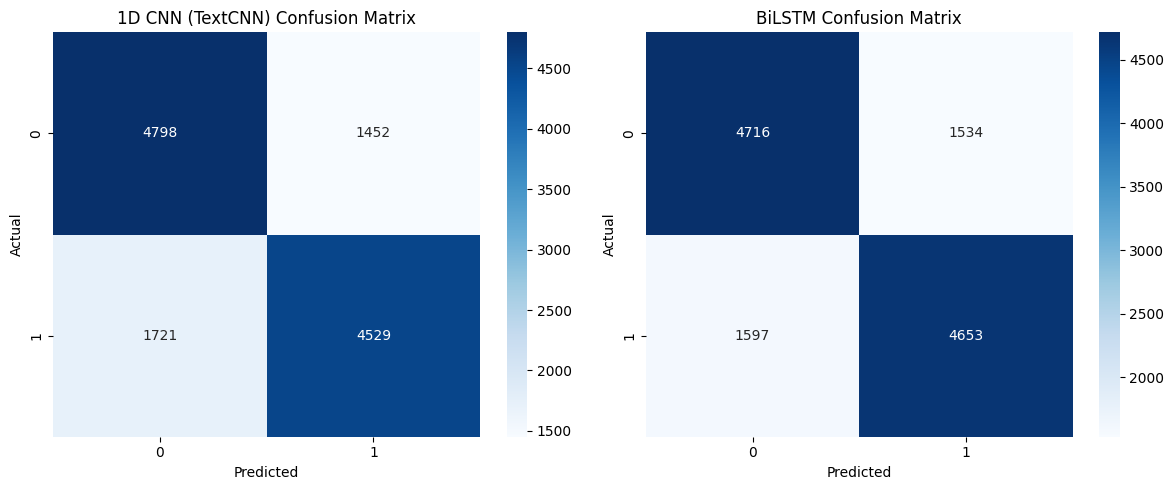

391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 64s 164ms/step


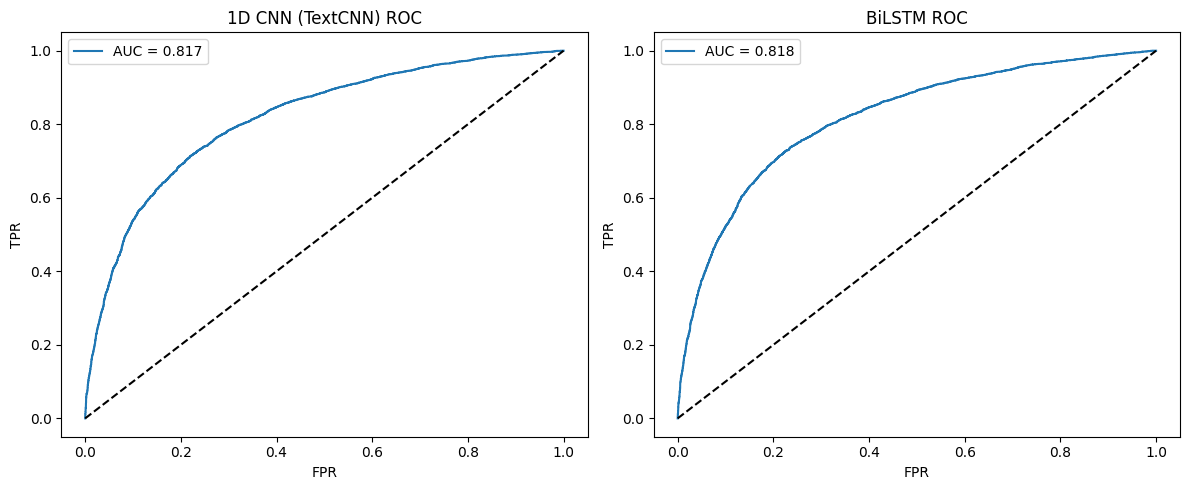

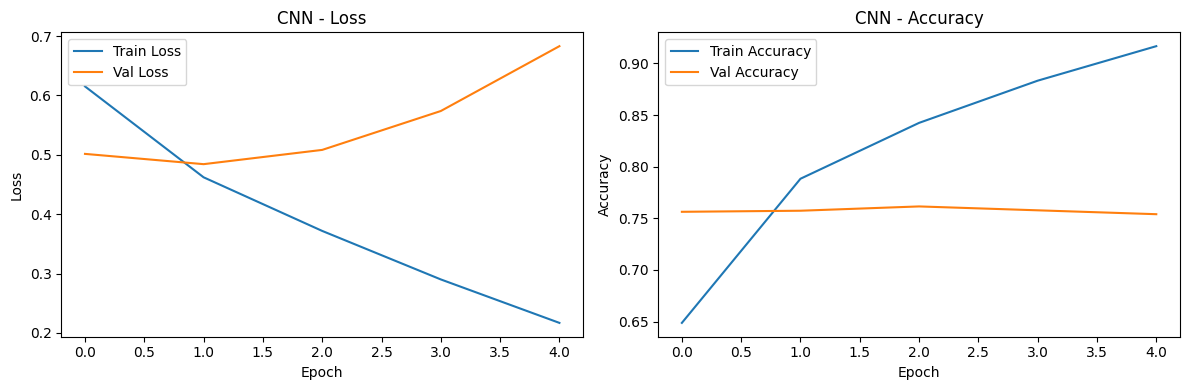

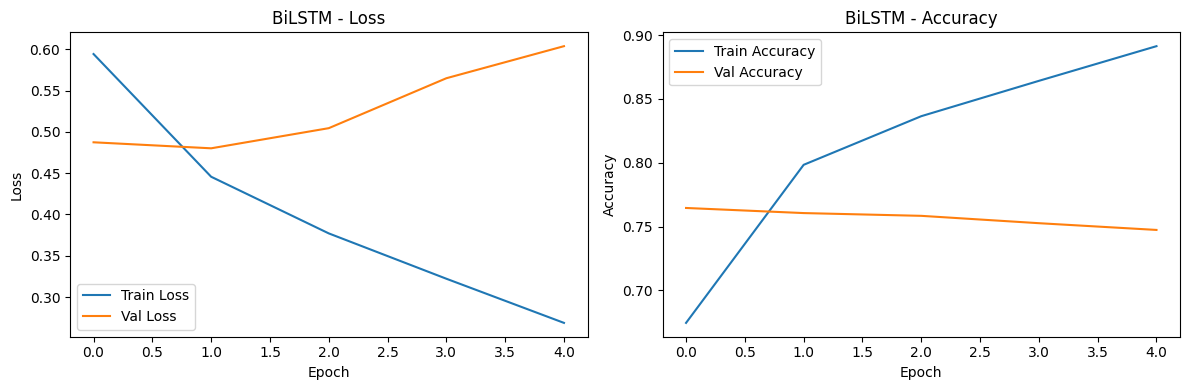


 Task 4 Completed - All metrics, plots and confusion matrices generated


In [34]:
#  TASK 4: Performance Evaluation Metrics

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# TRAINING CNN MODEL
print("Training 1D CNN Model...")
history_cnn = model_cnn.fit(X_train, y_train,
                            validation_data=(X_val, y_val),
                            epochs=5,
                            batch_size=128,
                            verbose=1)

# TRAINING BiLSTM MODEL
print("\nTraining BiLSTM Model...")
history_bilstm = model_bilstm.fit(X_train, y_train,
                                  validation_data=(X_val, y_val),
                                  epochs=5,
                                  batch_size=128,
                                  verbose=1)

# PREDICTIONS ON TEST SET
y_pred_cnn = (model_cnn.predict(X_test) > 0.5).astype(int).flatten()
y_pred_bilstm = (model_bilstm.predict(X_test) > 0.5).astype(int).flatten()

# CLASSIFICATION REPORTS
print("\n1D CNN (TextCNN) Results:")
print(classification_report(y_test, y_pred_cnn, digits=4))

print("\nBiLSTM Results:")
print(classification_report(y_test, y_pred_bilstm, digits=4))

# CONFUSION MATRICES
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CNN Confusion Matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('1D CNN (TextCNN) Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# BiLSTM Confusion Matrix
cm_bilstm = confusion_matrix(y_test, y_pred_bilstm)
sns.heatmap(cm_bilstm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('BiLSTM Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ROC CURVES
plt.figure(figsize=(12, 5))

# CNN ROC
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, model_cnn.predict(X_test))
auc_cnn = auc(fpr_cnn, tpr_cnn)
plt.subplot(1, 2, 1)
plt.plot(fpr_cnn, tpr_cnn, label=f'AUC = {auc_cnn:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('1D CNN (TextCNN) ROC')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

# BiLSTM ROC
fpr_bilstm, tpr_bilstm, _ = roc_curve(y_test, model_bilstm.predict(X_test))
auc_bilstm = auc(fpr_bilstm, tpr_bilstm)
plt.subplot(1, 2, 2)
plt.plot(fpr_bilstm, tpr_bilstm, label=f'AUC = {auc_bilstm:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('BiLSTM ROC')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

plt.tight_layout()
plt.show()

# TRAINING vs VALIDATION PLOTS
def plot_history(history, model_name):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_cnn, "CNN")
plot_history(history_bilstm, "BiLSTM")

print("\n Task 4 Completed - All metrics, plots and confusion matrices generated")